# Session 14 — Python Exercises: SOLUTIONS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.io import loadmat
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Exercise 1 — SOLUTION

In [2]:
d = loadmat('../data/exercise_anova.mat')
low, medium, high = d['low'].ravel(), d['medium'].ravel(), d['high'].ravel()

for nm, x in [('low', low), ('medium', medium), ('high', high)]:
    print(f'{nm:7s} mean={x.mean():5.2f}  SEM={x.std(ddof=1)/np.sqrt(x.size):.2f} Hz')

F, p = stats.f_oneway(low, medium, high)
N = low.size + medium.size + high.size
print(f'\nANOVA: F(2,{N-3}) = {F:.2f}, p = {p:.3e}')     # F(2,42)=39.0, p~3e-10

vals = np.concatenate([low, medium, high])
labs = ['low']*low.size + ['medium']*medium.size + ['high']*high.size
print(pairwise_tukeyhsd(vals, labs))   # all three pairs differ (low<medium<high)

low     mean=12.12  SEM=0.60 Hz
medium  mean=18.10  SEM=0.89 Hz
high    mean=22.39  SEM=0.94 Hz

ANOVA: F(2,42) = 38.99, p = 2.676e-10
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
  high    low -10.2686    0.0 -13.1065 -7.4307   True
  high medium  -4.2906 0.0019  -7.1285 -1.4527   True
   low medium    5.978    0.0   3.1401  8.8159   True
-----------------------------------------------------


## Exercise 2 — SOLUTION

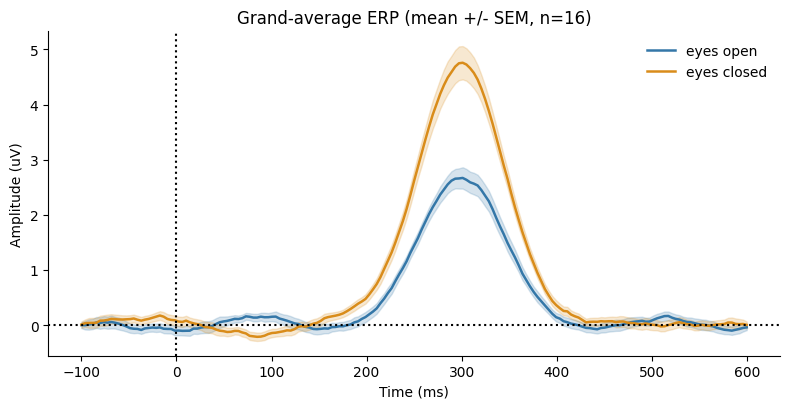

peak: open=2.67 uV, closed=4.76 uV


In [3]:
f = loadmat('../data/exercise_figure.mat')
erp_open, erp_closed = f['erp_open'], f['erp_closed']
time_ms = f['erp_time'].ravel() * 1000
n = erp_open.shape[0]

ga_o, ga_c = erp_open.mean(axis=0), erp_closed.mean(axis=0)
sem_o = erp_open.std(axis=0, ddof=1) / np.sqrt(n)
sem_c = erp_closed.std(axis=0, ddof=1) / np.sqrt(n)

fig, ax = plt.subplots(figsize=(8, 4.2))
for ga, sem, c, lab in [(ga_o, sem_o, '#3477a8', 'eyes open'),
                        (ga_c, sem_c, '#d98c1a', 'eyes closed')]:
    ax.plot(time_ms, ga, color=c, lw=1.8, label=lab)
    ax.fill_between(time_ms, ga-sem, ga+sem, color=c, alpha=0.2)
ax.axvline(0, color='k', ls=':'); ax.axhline(0, color='k', ls=':')
ax.set(xlabel='Time (ms)', ylabel='Amplitude (uV)',
       title=f'Grand-average ERP (mean +/- SEM, n={n})')
ax.legend(frameon=False)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
print(f'peak: open={ga_o.max():.2f} uV, closed={ga_c.max():.2f} uV')

## Exercise 3 — SOLUTION

placebo    mean peak = 3.17 +/- 0.25 uV
low_dose   mean peak = 4.89 +/- 0.24 uV
high_dose  mean peak = 6.72 +/- 0.33 uV

ANOVA: F(2,39) = 40.36, p = 3.169e-10


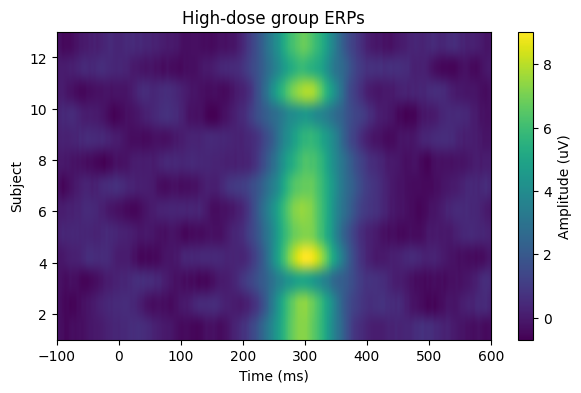

In [4]:
h = loadmat('../data/homework_s13.mat')
erp = {'placebo': h['erp_placebo'], 'low_dose': h['erp_low_dose'],
       'high_dose': h['erp_high_dose']}
erp_time = h['erp_time'].ravel()
mask = (erp_time >= 0.25) & (erp_time <= 0.45)

peaks = {k: v[:, mask].max(axis=1) for k, v in erp.items()}
for k, pk in peaks.items():
    print(f'{k:10s} mean peak = {pk.mean():.2f} +/- {pk.std(ddof=1)/np.sqrt(pk.size):.2f} uV')

F, p = stats.f_oneway(peaks['placebo'], peaks['low_dose'], peaks['high_dose'])
N = sum(pk.size for pk in peaks.values())
print(f'\nANOVA: F(2,{N-3}) = {F:.2f}, p = {p:.3e}')     # F(2,39)=40.4, p~3e-10

# erp-image for the high-dose group
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(erp['high_dose'], aspect='auto', origin='lower', cmap='viridis',
               extent=[erp_time[0]*1000, erp_time[-1]*1000, 1, erp['high_dose'].shape[0]])
ax.set(xlabel='Time (ms)', ylabel='Subject', title='High-dose group ERPs')
fig.colorbar(im, ax=ax, label='Amplitude (uV)'); plt.show()